# Vanilla RNN и LSTM с нуля

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
torch.manual_seed(0); np.random.seed(0)

## Данные

Синусоида с шумом, окно длины `L=20`, цель — предсказать следующее значение. Вспомогательная часть, её писать не нужно.

In [2]:
N = 10000
t = np.arange(N)
series = np.sin(2 * np.pi * t / 50) + 0.1 * np.random.randn(N)

L = 100
X = np.stack([series[i:i+L]   for i in range(N - L)])
Y = np.array (  [series[i+L]   for i in range(N - L)])
X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)
Y = torch.tensor(Y, dtype=torch.float32).unsqueeze(-1)

split = 800
X_tr, Y_tr = X[:split], Y[:split]
X_te, Y_te = X[split:], Y[split:]
X.shape, Y.shape

(torch.Size([9900, 100, 1]), torch.Size([9900, 1]))

In [3]:
series

array([ 0.17640523,  0.16534895,  0.34656369, ..., -0.31643733,
       -0.25198196,  0.00447791], shape=(10000,))

In [6]:
X

tensor([[[ 0.1764],
         [ 0.1653],
         [ 0.3466],
         ...,
         [-0.1895],
         [-0.2360],
         [-0.0851]],

        [[ 0.1653],
         [ 0.3466],
         [ 0.5922],
         ...,
         [-0.2360],
         [-0.0851],
         [ 0.1883]],

        [[ 0.3466],
         [ 0.5922],
         [ 0.6685],
         ...,
         [-0.0851],
         [ 0.1883],
         [-0.0094]],

        ...,

        [[-0.3610],
         [-0.0051],
         [-0.0282],
         ...,
         [-0.5862],
         [-0.7687],
         [-0.4775]],

        [[-0.0051],
         [-0.0282],
         [-0.0933],
         ...,
         [-0.7687],
         [-0.4775],
         [-0.3164]],

        [[-0.0282],
         [-0.0933],
         [ 0.4119],
         ...,
         [-0.4775],
         [-0.3164],
         [-0.2520]]])

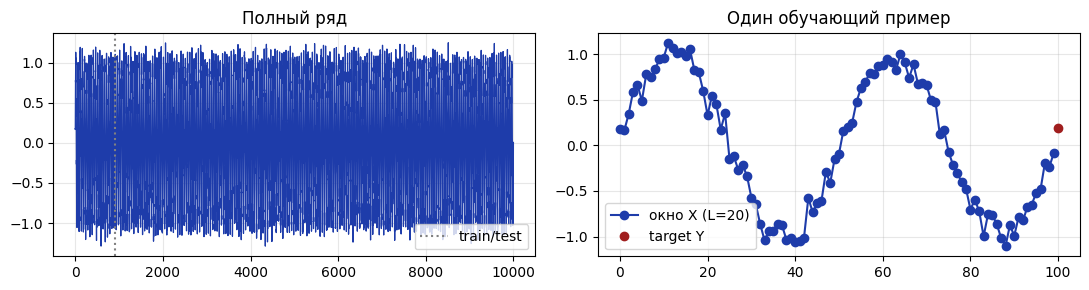

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3))
ax[0].plot(series, color='#1E3CAA', lw=0.9)
ax[0].axvline(split + L, color='gray', ls=':', label='train/test')
ax[0].set_title('Полный ряд'); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].plot(np.arange(L), X[0].squeeze(), 'o-', color='#1E3CAA', label='окно X (L=20)')
ax[1].plot([L], Y[0].squeeze(), 'o', color='#A01E1E', label='target Y')
ax[1].set_title('Один обучающий пример'); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Vanilla RNN Cell

На каждом шаге:

$$a_t = W_x\,x_t + W_h\,h_{t-1} + b,\qquad h_t = \tanh(a_t).$$

Размеры: $W_x\in\mathbb{R}^{n\times d}$, $W_h\in\mathbb{R}^{n\times n}$, $b\in\mathbb{R}^{n}$.

**Задание**: заполните `forward`.

In [ ]:
class VanillaRNNCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.W_x = nn.Parameter(torch.empty(hidden_size, input_size))
        self.W_h = nn.Parameter(torch.empty(hidden_size, hidden_size))
        self.b   = nn.Parameter(torch.zeros(hidden_size))
        nn.init.xavier_uniform_(self.W_x) # W_x (input weights): работают с нормализованными входными данными
        nn.init.orthogonal_(self.W_h) # W_h (recurrent weights): работают с активациями прошлого шага (могут быть нестабильны) охраняет градиенты от затухания во времени!

    def forward(self, x, h_prev):
        
        a_t = x @ self.W_x.T + h_prev @ self.W_h.T + self.b
        return torch.tanh(a_t)

## LSTM Cell

$$
\begin{aligned}
f_t &= \sigma(W_f\,[h_{t-1},x_t] + b_f), \quad i_t = \sigma(W_i\,[h_{t-1},x_t] + b_i) \\
\tilde c_t &= \tanh(W_c\,[h_{t-1},x_t] + b_c), \quad o_t = \sigma(W_o\,[h_{t-1},x_t] + b_o) \\
c_t &= f_t\odot c_{t-1} + i_t\odot \tilde c_t, \qquad h_t = o_t\odot \tanh(c_t)
\end{aligned}
$$

Четыре линейных преобразования объединяют в одну матрицу $W\in\mathbb{R}^{4n\times(n+d)}$ и режут результат на 4 куска. **bias forget-гейта инициализируется в 1** (Jozefowicz et al., 2015).

**Задание 1**: создать веса. **Задание 2**: реализовать `forward`.

In [9]:
class LSTMCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        """
        Инициализация LSTM ячейки.
        
        Процесс инициализации:
        1. Создаем пустую матрицу весов W размера (4*hidden_size, hidden_size+input_size)
        2. Создаем пустой вектор bias b размера (4*hidden_size)
        3. Инициализируем W методом Xavier Uniform (сохраняет дисперсию сигнала)
        4. Устанавливаем bias для forget gate = 1.0 (важно для начального запоминания!)
        
        Почему Xavier для W?
            - Сохраняет дисперсию сигнала между слоями
            - Предотвращает насыщение tanh и sigmoid
            - Обеспечивает здоровые градиенты на старте
        
        Почему bias forget gate = 1.0?
            - sigmoid(1) ≈ 0.73, а sigmoid(0) = 0.5
            - Заставляет LSTM изначально "запоминать", а не "забывать"
            - Критически важно для длинных последовательностей
            - Стандартная практика в PyTorch, TensorFlow, Keras
        """
        super().__init__()
        self.hidden_size = hidden_size
        # Создаем объединенную матрицу весов
        # Размер: [4 вентиля × hidden_size нейронов, входы = h_prev (hidden_size) + x (input_size)]
        self.W = nn.Parameter(torch.zeros(4 * hidden_size,hidden_size+input_size))
        self.b = nn.Parameter(torch.zeros(4 * hidden_size))

        nn.init.xavier_uniform_(self.W)
        with torch.no_grad(): # Отключаем градиенты для этой операции
            # bias для forget gate = 1 (важно!)
            self.b[:hidden_size].fill_(1.0)

    def forward(self, x, state):
        """
        Прямой проход LSTM ячейки.
        
        Аргументы:
            x (torch.Tensor): Вход формы (batch_size, input_size)
            state (tuple): (h_prev, c_prev), каждый формы (batch_size, hidden_size)
        
        Возвращает:
            h (torch.Tensor): Новое скрытое состояние (batch_size, hidden_size)
            (h, c) (tuple): Новое состояние для следующего шага
        """
        # Распаковываем состояние
        h_prev, c_prev = state
        
        # Шаг 1: Конкатенация [h_prev, x]
        # Размер: (batch_size, hidden_size + input_size)
        combined = torch.cat([h_prev, x], dim=1)
        
        # Шаг 2: Одно матричное умножение для всех вентилей
        # Размер: (batch_size, 4 * hidden_size)
        # ВАЖНО: результат имеет размер (B, 4n), а НЕ (4n, B)!
        gates = combined @ self.W.T + self.b
        
        # Шаг 3: Разделяем на 4 компонента
        n = self.hidden_size
        # gates[:, :n]     - forget gate (первые n элементов)
        # gates[:, n:2n]   - input gate (следующие n)
        # gates[:, 2n:3n]  - candidate (следующие n)
        # gates[:, 3n:]    - output gate (последние n)
        f = gates[:, :n]      # forget gate
        i = gates[:, n:2*n]   # input gate  
        g = gates[:, 2*n:3*n] # candidate (c_tilde)
        o = gates[:, 3*n:]    # output gate
        
        # Шаг 4: Применяем активации
        f = torch.sigmoid(f)   # forget: 0 = забыть, 1 = сохранить
        i = torch.sigmoid(i)   # input:  0 = игнорировать, 1 = записать
        g = torch.tanh(g)      # candidate: новые значения (-1 до 1)
        o = torch.sigmoid(o)   # output: 0 = ничего, 1 = всё
        
        # Шаг 5: Обновляем ячейку памяти
        # c_t = f_t * c_{t-1} + i_t * g_t
        c = f * c_prev + i * g
        
        # Шаг 6: Вычисляем скрытое состояние
        # h_t = o_t * tanh(c_t)
        h = o * torch.tanh(c)
        
        # Возвращаем новое скрытое состояние и новое состояние ячейки
        return h, (h, c)

## Обёртка: применяем ячейку ко всей последовательности

In [25]:
class SeqModel(nn.Module):
    def __init__(self, cell, hidden_size, output_size=1):
        super().__init__()
        self.cell = cell
        self.hidden_size = hidden_size
        self.head = nn.Linear(hidden_size, output_size)
        self.is_lstm = isinstance(cell, LSTMCell)

    def forward(self, x):
        B, T, _ = x.shape
        h = torch.zeros(B, self.hidden_size, device=x.device)
        if self.is_lstm:
            c = torch.zeros(B, self.hidden_size, device=x.device)
            state = (h, c)
            for t in range(T):
                _, state = self.cell(x[:, t], state)
            return self.head(state[0])
        for t in range(T):
            h = self.cell(x[:, t], h)
        return self.head(h)

## Обучение с трекингом нормы градиента

Будем сохранять `||∇||` до клиппинга — это позволит сравнить gradient flow в RNN и LSTM.

In [33]:
def train(model, X_tr, Y_tr, X_te, Y_te, epochs=80, lr=5e-3):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.MSELoss()
    h = {'train': [], 'val': [], 'gnorm': []}
    for _ in range(epochs):
        model.train()
        pred = model(X_tr)
        loss = crit(pred, Y_tr)
        opt.zero_grad(); loss.backward()
        gn = 0
        opt.step()
        model.eval()
        with torch.no_grad():
            val = crit(model(X_te), Y_te).item()
        h['train'].append(loss.item()); h['val'].append(val); h['gnorm'].append(gn)
    return h

In [40]:
HIDDEN = 64
rnn  = SeqModel(VanillaRNNCell(1, HIDDEN), HIDDEN)
lstm = SeqModel(LSTMCell(1, HIDDEN),       HIDDEN)
h_rnn  = train(rnn,  X_tr, Y_tr, X_te, Y_te)
h_lstm = train(lstm, X_tr, Y_tr, X_te, Y_te)

## Визуализация: 4 панели

Loss train, loss val, gradient norm, предсказания на тесте.

/tmp/ipykernel_58/261977899.py:7: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax[1,0].set_title(r'$\|\nabla\|$ до клиппинга'); ax[1,0].set_yscale('log')


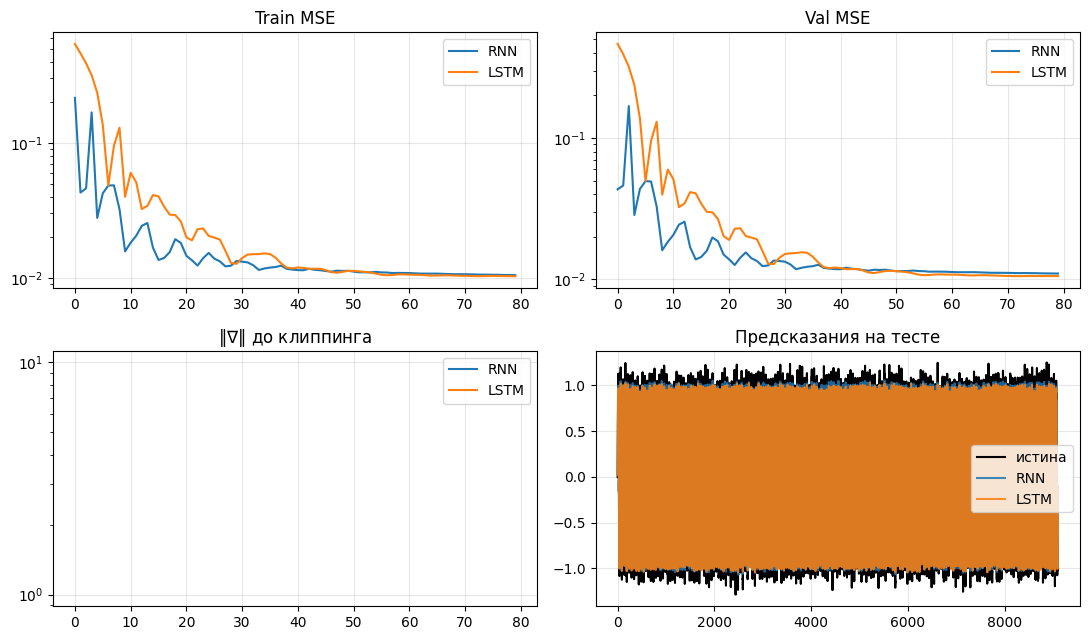

In [42]:
fig, ax = plt.subplots(2, 2, figsize=(11, 6.5))
ax[0,0].plot(h_rnn['train'],  label='RNN');  ax[0,0].plot(h_lstm['train'], label='LSTM')
ax[0,0].set_title('Train MSE');  ax[0,0].set_yscale('log'); ax[0,0].legend(); ax[0,0].grid(alpha=0.3)
ax[0,1].plot(h_rnn['val'],    label='RNN');  ax[0,1].plot(h_lstm['val'],   label='LSTM')
ax[0,1].set_title('Val MSE');    ax[0,1].set_yscale('log'); ax[0,1].legend(); ax[0,1].grid(alpha=0.3)
ax[1,0].plot(h_rnn['gnorm'],  label='RNN');  ax[1,0].plot(h_lstm['gnorm'], label='LSTM')
ax[1,0].set_title(r'$\|\nabla\|$ до клиппинга'); ax[1,0].set_yscale('log')
ax[1,0].legend(); ax[1,0].grid(alpha=0.3)
with torch.no_grad():
    p_rnn  = rnn (X_te).squeeze().numpy()
    p_lstm = lstm(X_te).squeeze().numpy()
ax[1,1].plot(Y_te.squeeze().numpy(), 'k', lw=1.5, label='истина')
ax[1,1].plot(p_rnn,  label='RNN',  alpha=0.85)
ax[1,1].plot(p_lstm, label='LSTM', alpha=0.85)
ax[1,1].set_title('Предсказания на тесте'); ax[1,1].legend(); ax[1,1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Residuals: распределение ошибок

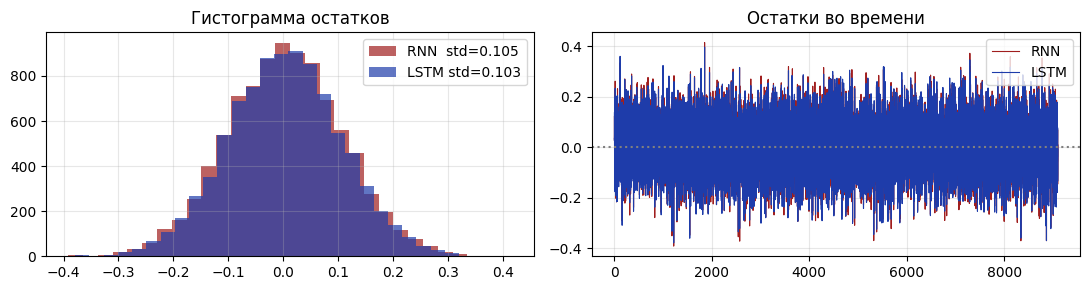

In [43]:
res_rnn  = (p_rnn  - Y_te.squeeze().numpy())
res_lstm = (p_lstm - Y_te.squeeze().numpy())
fig, ax = plt.subplots(1, 2, figsize=(11, 3))
ax[0].hist(res_rnn,  bins=30, color='#A01E1E', alpha=0.7, label=f'RNN  std={res_rnn.std():.3f}')
ax[0].hist(res_lstm, bins=30, color='#1E3CAA', alpha=0.7, label=f'LSTM std={res_lstm.std():.3f}')
ax[0].set_title('Гистограмма остатков'); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].plot(res_rnn,  color='#A01E1E', lw=0.8, label='RNN')
ax[1].plot(res_lstm, color='#1E3CAA', lw=0.8, label='LSTM')
ax[1].axhline(0, color='gray', ls=':')
ax[1].set_title('Остатки во времени'); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()



- Почему `nn.init.orthogonal_` для `W_h` в RNN? Что даёт это для $\sigma_{\max}(W_h)$?
- Почему bias forget-гейта инициализируется в 1? Что было бы при $b_f=0$?
- Зачем `clip_grad_norm_`? Посмотрите панель $\|\nabla\|$ — заметна ли разница RNN vs LSTM?
- Если увеличить `L` до 200, как поведут себя обе модели? Попробуйте.